In [36]:
# Optuna hyperparameter summary table (for slides)
import pandas as pd
import optuna
from pathlib import Path

try:
    current_location = Path(__file__).resolve().parent
except NameError:
    current_location = Path.cwd().resolve()

if current_location.name in ["Finalized_Scripts", "Test_Scripts", "scripts"]:
    PROJECT_ROOT = current_location.parent
else:
    PROJECT_ROOT = current_location

db_path = PROJECT_ROOT / "Data_Files" / "floodnet_hpo_newfilter.db"
storage = f"sqlite:///{db_path}"

study_names = ["log_ridge", "res_ann", "attn_lstm"]
rows = []

if not db_path.exists():
    print(f"Optuna DB not found: {db_path}")
else:
    for name in study_names:
        try:
            study = optuna.load_study(study_name=name, storage=storage)
            row = {
                "model": name,
                "best_val_nse": round(float(study.best_value), 4),
                "n_trials": len(study.trials),
            }
            for k, v in study.best_params.items():
                row[k] = v
            rows.append(row)
        except Exception as e:
            rows.append({"model": name, "error": str(e)})

    hpo_params_table = pd.DataFrame(rows)
    display(hpo_params_table)
    # Optional export for slides:
hpo_params_table.to_csv(PROJECT_ROOT / "results" / "hpo_best_params_table.csv", index=False)


,model,best_val_nse,n_trials,alpha,log_shift,target_transform,hidden_size,n_layers,lr,dropout,weight_decay,loss_fn,use_weighted_loss,loss_lambda,batch_size,window_size
0,log_ridge,0.4769,800,0.000198,0.056342,log,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,res_ann,0.4429,531,NaN,NaN,NaN,640.0,4.0,0.000050,0.148829,1.122568e-08,mse,False,0.145719,16384.0,NaN
2,attn_lstm,0.5729,143,NaN,NaN,NaN,256.0,3.0,0.000986,0.045692,2.458603e-08,huber,NaN,NaN,NaN,30.0


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import optuna
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import folium
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pathlib import Path

In [38]:
# 1. Identify the current directory (Handles both .py scripts and Jupyter)
try:
    # Use __file__ for standalone scripts
    current_location = Path(__file__).resolve().parent
except NameError:
    # Use Current Working Directory for Jupyter/Interactive sessions
    current_location = Path.cwd().resolve()

# 2. Navigate to the actual Project Root
# If current_location is 'Finalized_Scripts', move to the parent directory
if current_location.name in ["Finalized_Scripts", "Test_Scripts", "scripts"]:
    PROJECT_ROOT = current_location.parent
else:
    PROJECT_ROOT = current_location

# 3. Define the absolute path to the data
# This ensures the path is /floodnet_work/Data_Files/ instead of /Finalized_Scripts/Data_Files/
data_dir = PROJECT_ROOT / "Data_Files"
file_name = "rain_influenced_gages.parquet"
file_path = data_dir / file_name

# 4. Safety Check and Data Loading
if not file_path.exists():
    # This will print the exact path being searched to help with troubleshooting
    raise FileNotFoundError(f"Target file not found at: {file_path}")

df = pd.read_parquet(file_path)

print(f"Successfully loaded data from: {file_path}")

Successfully loaded data from: /sfs/gpfs/tardis/home/upw4ys/Documents/floodnet_work/Data_Files/rain_influenced_gages.parquet


In [39]:
# Convert time to datetime if not already
df['time'] = pd.to_datetime(df['time'])

# Downcast floats to save 50% RAM for EDA [cite: 14, 15]
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype('float32')

print(f"✅ Data Loaded: {len(df):,} rows.")
print(f"Current Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

✅ Data Loaded: 7 rows.
Current Memory Usage: 0.00 MB


In [40]:
#df_storms = df[df['deployment_id'] == 'apparently-darling-gecko'].copy()
df_storms = df

In [41]:
df_storms.columns

Index(['deployment_id', 'time', 'depth_proc_mm', 'depth_inches', 'name',
       'date_deployed', 'date_down', 'coordinates', 'borough', 'latitude',
       'longitude', 'STATION', 'dist_to_station_ft', 'weather_time',
       'elevation [feet]', 'temp_2m [degF]', 'relative_humidity [percent]',
       'dewpoint [degF]', 'precip_incremental [inch]',
       'precip_max_intensity [inch/hour]', 'precip_1hr [inch]',
       'frozen_soil_05cm [bit]', 'frozen_soil_25cm [bit]',
       'frozen_soil_50cm [bit]', 'soil_temp_05cm [degF]',
       'soil_temp_25cm [degF]', 'soil_temp_50cm [degF]',
       'soil_moisture_05cm [m^3/m^3]', 'soil_moisture_25cm [m^3/m^3]',
       'soil_moisture_50cm [m^3/m^3]', 'snow_depth [inch]', 'DATE', 'storm_id',
       'global_storm_id', 'storm_start', 'storm_end', 'rain_start', 'rain_end',
       'phase', 'hours_since_rain_start', 'hours_since_storm_start',
       'minutes_since_weather_update', 'total_precip_in', 'peak_intensity_inh',
       'intensity_hits_ge_threshol

In [42]:
def calculate_nse(y_true, y_pred):
    """Hydroinformatics standard: Nash-Sutcliffe Efficiency"""
    return 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))

def objective(trial):
    # AUTOMATED PARAMETER TUNING
    # Example for Logarithmic Regression Baseline
    shift_value = trial.suggest_float("log_shift", 0.001, 0.1) # Handle log(0)
    
    # Prep features (Precip, Soil Moisture, etc.)
    X = df_storms[['precip_1hr [inch]', 'soil_moisture_05cm [m^3/m^3]']].fillna(0)
    y = np.log(df_storms['depth_inches'] + shift_value)
    
    # Train/Test Split
    model = LinearRegression().fit(X, y)
    preds = np.exp(model.predict(X)) - shift_value
    
    # Maximize NSE
    score = calculate_nse(df_storms['depth_inches'], preds)
    return score

# Create the study to maximize the best-performing version
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

[I 2026-04-30 13:29:00,934] A new study created in memory with name: no-name-7e3e28ad-259d-46e8-86ae-7afd60470e25
[I 2026-04-30 13:29:00,941] Trial 0 finished with value: -0.04964864253997803 and parameters: {'log_shift': 0.09042434769483589}. Best is trial 0 with value: -0.04964864253997803.
[I 2026-04-30 13:29:00,943] Trial 1 finished with value: -0.05232572555541992 and parameters: {'log_shift': 0.008017569106798555}. Best is trial 0 with value: -0.04964864253997803.
[I 2026-04-30 13:29:00,945] Trial 2 finished with value: -0.05110466480255127 and parameters: {'log_shift': 0.04504939120483912}. Best is trial 0 with value: -0.04964864253997803.
[I 2026-04-30 13:29:00,948] Trial 3 finished with value: -0.050452470779418945 and parameters: {'log_shift': 0.06520513150609253}. Best is trial 0 with value: -0.04964864253997803.
[I 2026-04-30 13:29:00,950] Trial 4 finished with value: -0.04984700679779053 and parameters: {'log_shift': 0.08416252969006473}. Best is trial 0 with value: -0.049

In [43]:
sensor_list = df_storms['deployment_id'].unique().tolist()
print(f"Total Sensors: {len(sensor_list)}")
print("Available IDs:", sensor_list)

Total Sensors: 3
Available IDs: ['BK-kent-ave-wallabout-st-19r2g0', 'BK-ocean-ave-dorchester-rd-1lbi40', 'Q-holly-ave-union-st-1vcow0']


In [44]:
df_storms[['latitude', 'longitude']].isna().sum()

latitude     0
longitude    0
dtype: int64

In [45]:
# 1. List all unique sensors
sensor_names = df_storms['deployment_id'].unique().tolist()
print(f"✅ Total unique sensors found: {len(sensor_names)}")
print(f"Sample IDs: {sensor_names[:10]}")

# 2. Create the Spatial Map (NAD83 / New York Long Island Context)
def create_sensor_map(df):
    # Aggregate max depth per sensor for visual scaling
    map_data = df.groupby(['deployment_id', 'latitude', 'longitude'])['depth_inches'].max().reset_index()
    
    # Initialize NYC Map
    m = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB Positron')
    
    for _, row in map_data.iterrows():
    # 1. Scale the radius: 1.5 pixels per inch of flood
    # 2. Set a 'floor' of 3 pixels so dry sensors are still visible
    # 3. Use a square root for 'area-based' scaling (more scientifically accurate)
        scaled_radius = row['depth_inches'] * 0.5
    
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=scaled_radius, 
            popup=f"ID: {row['deployment_id']}<br>Max Depth: {row['depth_inches']:.2f} in",
            color='#e74c3c',
            fill=True,
            fill_opacity=0.5,
            weight=1
        ).add_to(m)
    return m

# Display map in Colab
nyc_map = create_sensor_map(df_storms)
nyc_map

✅ Total unique sensors found: 3
Sample IDs: ['BK-kent-ave-wallabout-st-19r2g0', 'BK-ocean-ave-dorchester-rd-1lbi40', 'Q-holly-ave-union-st-1vcow0']


In [46]:
def plot_individual_storms(df, sensor_id):
    # 1. Filter and sort sensor data
    sensor_data = df[df['deployment_id'] == sensor_id].sort_values('time').copy()
    
    if sensor_data.empty:
        print(f"❌ No data found for ID: {sensor_id}")
        return

    # 2. EVENT ID LOGIC: Group rows where time gap <= 120 minutes
    # This prevents the "400k events" error by keeping buffers together
    sensor_data['time_diff'] = sensor_data['time'].diff().dt.total_seconds() / 60
    sensor_data['event_id'] = (sensor_data['time_diff'] > 120).cumsum()
    
    unique_events = sensor_data['event_id'].unique()
    print(f"🔍 Found {len(unique_events)} discrete storm windows for {sensor_id}.")

    # 3. Plotting Loop
    for eid in unique_events:
        subset = sensor_data[sensor_data['event_id'] == eid]
        
        # Filtering out 'noise' (events shorter than 6 hours)
        if len(subset) < 360:
            continue
            
        fig, ax1 = plt.subplots(figsize=(14, 6), dpi=100)

        # Primary Axis: Water Depth (Black)
        color_depth = '#1a1a1a'
        ax1.set_xlabel('Time (UTC)', fontsize=10)
        ax1.set_ylabel('Water Depth (inches)', color=color_depth, fontsize=12, fontweight='bold')
        ax1.plot(subset['time'], subset['depth_inches'], color=color_depth, linewidth=2, label='Depth')
        ax1.fill_between(subset['time'], subset['depth_inches'], color=color_depth, alpha=0.1)
        ax1.tick_params(axis='y', labelcolor=color_depth)

        # Secondary Axis: Precipitation (Blue - Inverted)
        ax2 = ax1.twinx()
        color_rain = '#0072B2'
        ax2.set_ylabel('1-hr Precipitation (inches)', color=color_rain, fontsize=12, fontweight='bold')
        ax2.bar(subset['time'], subset['precip_1hr [inch]'], color=color_rain, width=0.005, alpha=0.6, label='Precip')
        
        # Scaling and Inversion
        max_rain = subset['precip_1hr [inch]'].max()
        ax2.set_ylim(max(max_rain * 4, 0.5), 0) 
        ax2.tick_params(axis='y', labelcolor=color_rain)

        # Title and Formatting
        event_start = subset['time'].min().strftime('%Y-%m-%d')
        plt.title(f"Storm Event Analysis: {sensor_id} | Starting {event_start}", fontsize=14, pad=15)
        plt.grid(True, linestyle='--', alpha=0.3)
        
        fig.tight_layout()
        plt.show()

# --- INTERACTIVE EXECUTION ---
plot_individual_storms(df_storms, "apparently-darling-gecko")

❌ No data found for ID: apparently-darling-gecko


In [47]:
df_storms

,deployment_id,time,depth_proc_mm,depth_inches,name,date_deployed,date_down,coordinates,borough,latitude,...,phase,hours_since_rain_start,hours_since_storm_start,minutes_since_weather_update,total_precip_in,peak_intensity_inh,intensity_hits_ge_threshold,net_depth_rise_in,storm_record_count,storm_duration_hr
0,BK-kent-ave-wallabout-st-19r2g0,2023-09-29 12:19:12+00:00,297.941986,11.73,BK - Kent Ave/Wallabout St,2023-03-09,NaT,POINT (-73.960584 40.699336),Brooklyn,40.699337,...,storm,0.0,2.0,4.200000,0.248,3.24,1,0.0,1,8.0
1,BK-kent-ave-wallabout-st-19r2g0,2025-10-30 19:03:42+00:00,208.026001,8.19,BK - Kent Ave/Wallabout St,2023-03-09,NaT,POINT (-73.960584 40.699336),Brooklyn,40.699337,...,storm,0.0,2.0,3.700000,0.352,7.06,1,0.0,1,8.0
2,BK-ocean-ave-dorchester-rd-1lbi40,2024-06-14 23:00:12+00:00,74.930000,2.95,BK - Ocean Ave/Dorchester Rd,2023-10-20,NaT,POINT (-73.959463 40.641051),Brooklyn,40.641052,...,storm,0.0,2.0,0.200000,0.258,4.89,1,0.0,1,8.0
3,BK-ocean-ave-dorchester-rd-1lbi40,2025-07-31 20:14:33+00:00,114.045998,4.49,BK - Ocean Ave/Dorchester Rd,2023-10-20,NaT,POINT (-73.959463 40.641051),Brooklyn,40.641052,...,storm,0.0,2.0,4.550000,0.182,2.67,1,0.0,1,8.0
4,BK-ocean-ave-dorchester-rd-1lbi40,2025-10-30 18:57:53+00:00,153.923996,6.06,BK - Ocean Ave/Dorchester Rd,2023-10-20,NaT,POINT (-73.959463 40.641051),Brooklyn,40.641052,...,storm,0.0,2.0,2.883333,0.352,7.63,1,0.0,1,8.0
5,Q-holly-ave-union-st-1vcow0,2024-08-19 00:35:05+00:00,78.994003,3.11,Q - Holly Ave/Union St,2024-05-02,NaT,POINT (-73.817921 40.751463),Queens,40.751465,...,storm,0.0,2.0,0.083333,0.212,3.50,1,0.0,1,8.0
6,Q-holly-ave-union-st-1vcow0,2025-10-30 19:53:06+00:00,54.102001,2.13,Q - Holly Ave/Union St,2024-05-02,NaT,POINT (-73.817921 40.751463),Queens,40.751465,...,storm,0.0,2.0,3.100000,0.059,1.49,0,0.0,1,8.0


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

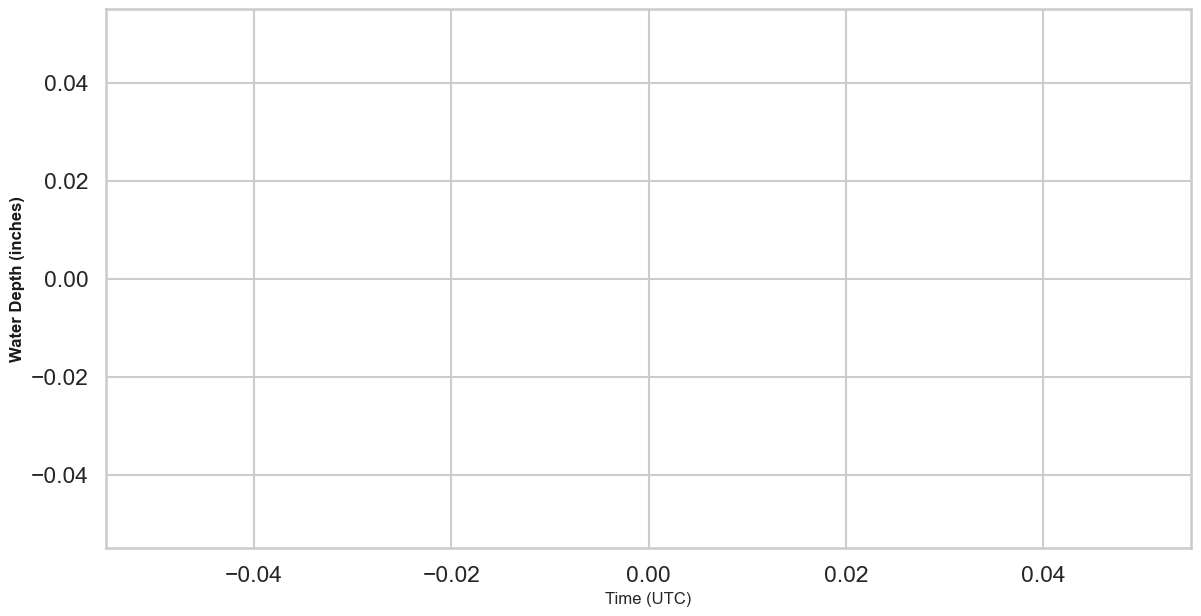

In [48]:
def plot_journal_hydrograph(df, sensor_id):
    # Subset data for a single sensor's event
    subset = df[df['deployment_id'] == sensor_id].sort_values('time')
    
    fig, ax1 = plt.subplots(figsize=(14, 7), dpi=100)

    # --- Axis 1: Flood Depth ---
    color_depth = '#1a1a1a' # Dark grey/black for clarity
    ax1.set_xlabel('Time (UTC)', fontsize=12)
    ax1.set_ylabel('Water Depth (inches)', color=color_depth, fontsize=12, fontweight='bold')
    ax1.plot(subset['time'], subset['depth_inches'], color=color_depth, linewidth=2.5, label='Observed Depth')
    ax1.fill_between(subset['time'], subset['depth_inches'], color=color_depth, alpha=0.15)
    ax1.tick_params(axis='y', labelcolor=color_depth)

    # --- Axis 2: Precipitation (Inverted) ---
    ax2 = ax1.twinx()
    color_rain = '#0072B2' # Hydrology Blue
    ax2.set_ylabel('1-hr Precipitation (inches)', color=color_rain, fontsize=12, fontweight='bold')
    ax2.bar(subset['time'], subset['precip_1hr [inch]'], color=color_rain, width=0.005, alpha=0.7, label='Precipitation')
    
    # Invert Axis 2: High rain comes from the top
    ax2.set_ylim(subset['precip_1hr [inch]'].max() * 4, 0) 
    ax2.tick_params(axis='y', labelcolor=color_rain)

    # Annotate the Buffers 
    plt.title(f"Detailed Storm Event Analysis: {sensor_id}", fontsize=14, pad=20)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    
    fig.tight_layout()
    plt.show()

plot_journal_hydrograph(df_storms, "apparently-darling-gecko")

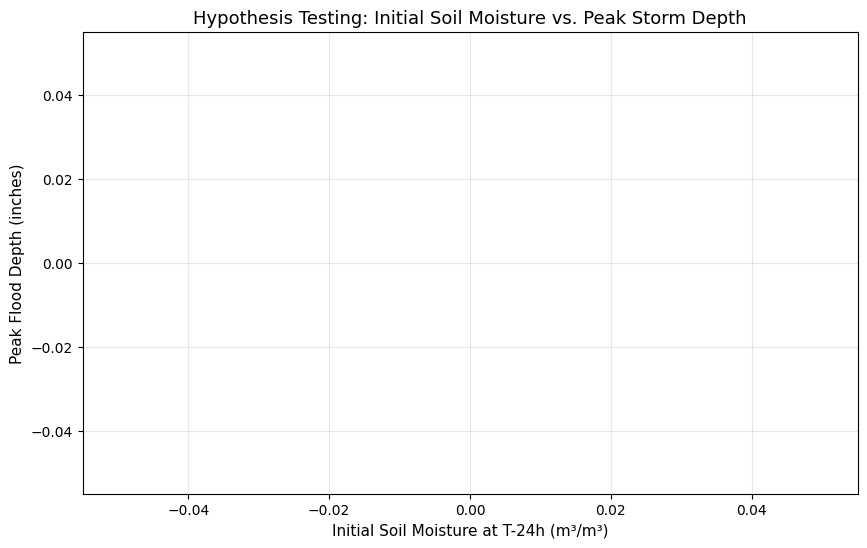

In [ ]:
def plot_antecedent_correlation(df):
    # Group by sensor/event to find starting moisture vs peak depth
    # We define 'starting moisture' as the first record in the 24h window
    event_stats = df.groupby('deployment_id').agg({
        'soil_moisture_05cm [m^3/m^3]': 'first',
        'depth_inches': 'max'
    }).rename(columns={'depth_inches': 'peak_depth', 'soil_moisture_05cm [m^3/m^3]': 'initial_moisture'})

    plt.figure(figsize=(10, 6))
    sns.regplot(x='initial_moisture', y='peak_depth', data=event_stats, 
                scatter_kws={'alpha':0.6, 'color':'#2c3e50'}, 
                line_kws={'color':'#e74c3c', 'lw':2})
    
    plt.title("Hypothesis Testing: Initial Soil Moisture vs. Peak Storm Depth", fontsize=13)
    plt.xlabel("Initial Soil Moisture at T-24h (m³/m³)", fontsize=11)
    plt.ylabel("Peak Flood Depth (inches)", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.show()

plot_antecedent_correlation(df_storms)

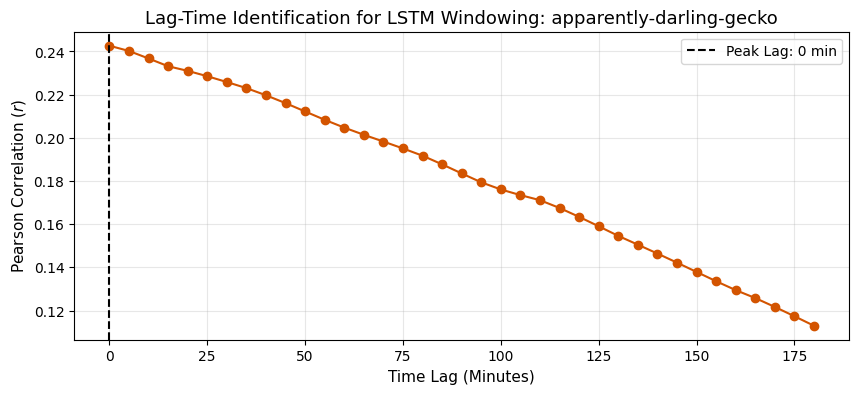

In [ ]:
def plot_lag_correlation(df, sensor_id):
    sensor_data = df[df['deployment_id'] == sensor_id].copy()
    
    # Calculate correlations at different lags (in 5-min increments)
    lags = np.arange(0, 37) * 5 # 0 to 180 minutes
    corrs = []
    
    for l in lags:
        # Shift precip forward to see correlation with depth
        shifted_rain = sensor_data['precip_1hr [inch]'].shift(l // 1) # Simplified lag
        corrs.append(sensor_data['depth_inches'].corr(shifted_rain))
        
    plt.figure(figsize=(10, 4))
    plt.plot(lags, corrs, marker='o', linestyle='-', color='#d35400')
    plt.axvline(lags[np.argmax(corrs)], color='black', linestyle='--', label=f'Peak Lag: {lags[np.argmax(corrs)]} min')
    
    plt.title(f"Lag-Time Identification for LSTM Windowing: {sensor_id}", fontsize=13)
    plt.xlabel("Time Lag (Minutes)", fontsize=11)
    plt.ylabel("Pearson Correlation ($r$)", fontsize=11)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_lag_correlation(df_storms, df_storms['deployment_id'].iloc[0])

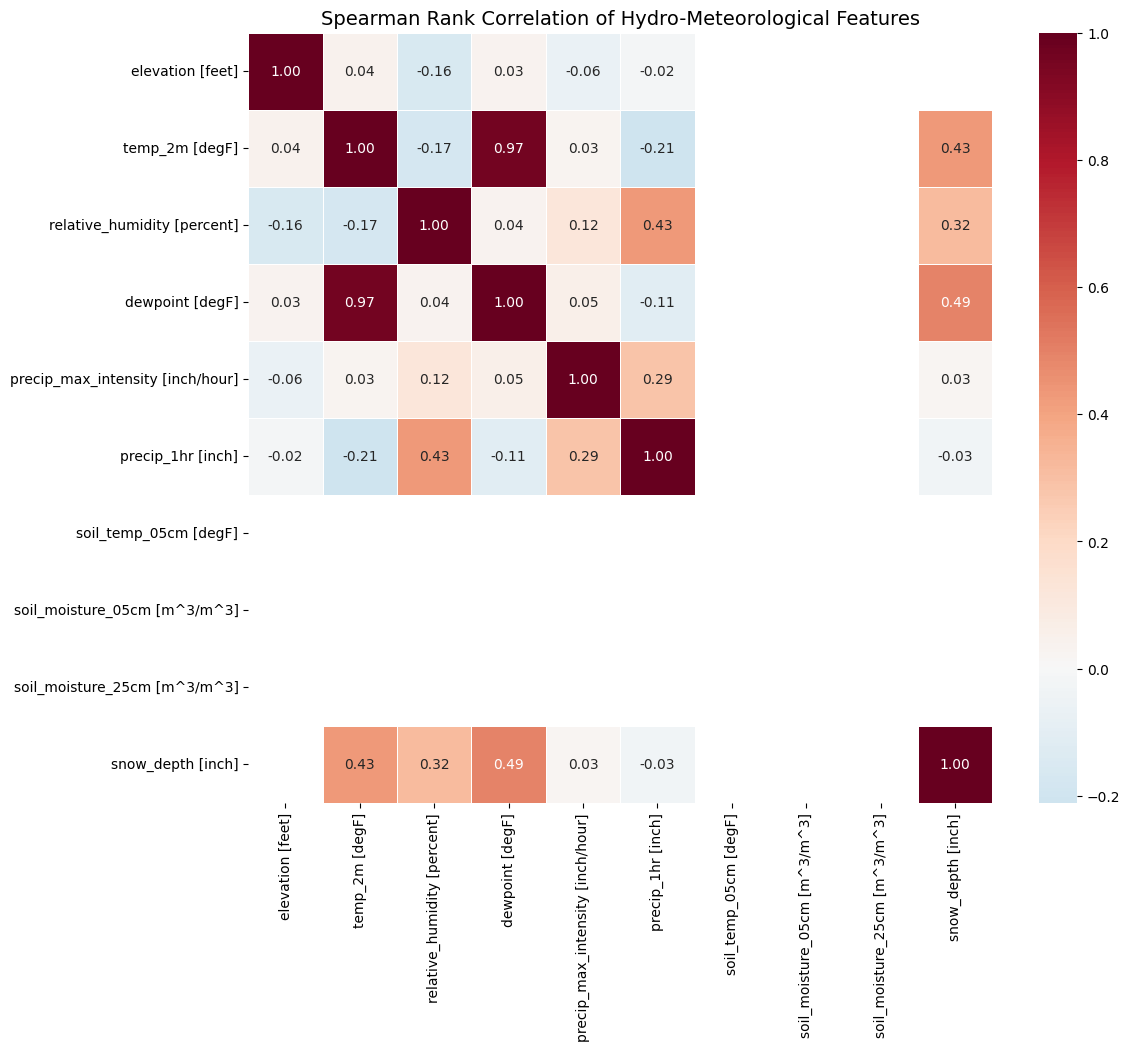

In [ ]:
def plot_correlation_heatmap(df):
    # Select the numerical columns most likely to be used as model features
    features = [
        'elevation [feet]', 'temp_2m [degF]', 'relative_humidity [percent]', 
        'dewpoint [degF]', 'precip_max_intensity [inch/hour]', 'precip_1hr [inch]',
        'soil_temp_05cm [degF]', 'soil_moisture_05cm [m^3/m^3]', 
        'soil_moisture_25cm [m^3/m^3]', 'snow_depth [inch]'
    ]
    
    # Calculate the correlation matrix
    corr_matrix = df[features].corr(method='spearman')

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
    plt.title("Spearman Rank Correlation of Hydro-Meteorological Features", fontsize=14)
    plt.show()

plot_correlation_heatmap(df_storms)

In [ ]:
def calculate_vif(df):
    # Select features and drop rows with NaNs (VIF requires clean data)
    features_to_test = [
        'temp_2m [degF]', 'relative_humidity [percent]', 'dewpoint [degF]',
        'soil_temp_05cm [degF]', 'soil_moisture_05cm [m^3/m^3]', 'elevation [feet]'
    ]
    
    X = df[features_to_test].dropna()
    X = add_constant(X) # Add intercept for VIF calculation

    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

    # Filter out the constant and sort
    return vif_data[vif_data["Feature"] != "const"].sort_values("VIF", ascending=False)

vif_results = calculate_vif(df_storms)
print(vif_results)

ValueError: zero-size array to reduction operation maximum which has no identity

In [49]:
# 1. Final Pruned Feature List
selected_features = [
    'precip_1hr [inch]', 
    'precip_max_intensity [inch/hour]', 
    'temp_2m [degF]', 
    'soil_temp_05cm [degF]', 
    'soil_moisture_05cm [m^3/m^3]', 
    'elevation [feet]'
]

# 2. Target Variable
target = 'depth_inches'

# 3. Create the modeling dataframe (dropping NaNs and downcasting)
df_model = df_storms[selected_features + [target]].dropna()

for col in selected_features:
    df_model[col] = df_model[col].astype('float32')
    
print(f"Modeling dataset ready with {len(df_model):,} rows and {len(selected_features)} features.")

Modeling dataset ready with 0 rows and 6 features.


In [50]:
def calculate_nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))

def objective(trial):
    # 1. Automated Parameter Tuning
    # 'c' prevents log(0) and adjusts the non-linear curve fit
    c = trial.suggest_float("log_shift", 1e-4, 0.5, log=True)
    
    # 2. Split Data
    X = df_model[selected_features]
    y = df_model[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 3. Log Transform Target
    y_train_log = np.log(y_train + c)
    
    # 4. Train Model
    model = LinearRegression()
    model.fit(X_train, y_train_log)
    
    # 5. Inverse Transform Predictions
    preds_log = model.predict(X_test)
    preds = np.exp(preds_log) - c
    
    # 6. Maximize NSE
    score = calculate_nse(y_test, preds)
    return score

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(f"Best Log-Regression NSE: {study.best_value:.4f}")
print(f"Best Log Shift (c): {study.best_params['log_shift']}")

[I 2026-04-30 13:29:20,453] A new study created in memory with name: no-name-206de359-98d9-4eec-9eee-fff665c10c7f
[W 2026-04-30 13:29:20,455] Trial 0 failed with parameters: {'log_shift': 0.0004478967993528732} because of the following error: ValueError('With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.').
Traceback (most recent call last):
  File "/home/upw4ys/Documents/floodnet_work/.venv/lib64/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_29383/3285872911.py", line 12, in objective
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/upw4ys/Documents/floodnet_work/.venv/lib64/python3.11/site-packages/sklearn/utils/_param_validation

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

## Hydrology Presentation Additions

These cells are designed to make the EDA notebook presentation-ready:
- clear hydrology narrative structure,
- event-based diagnostics,
- robustness checks, and
- export-ready figures.
        


### 1) Presentation Setup and Figure Style

Define a consistent plotting style and reusable settings for slide-quality output.
        


In [51]:
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

PRESENTATION_GAP_MIN = 120
KEY_VARS = [
    "depth_inches",
    "precip_1hr [inch]",
    "soil_moisture_05cm [m^3/m^3]",
    "temp_2m [degF]",
]

print(f"Rows: {len(df_storms):,}")
print(f"Sensors: {df_storms['deployment_id'].nunique()}")
print(f"Time span: {df_storms['time'].min()} to {df_storms['time'].max()}")
        


Rows: 7
Sensors: 3
Time span: 2023-09-29 12:19:12+00:00 to 2025-10-30 19:53:06+00:00


### 2) Data QA/QC Dashboard

Show data completeness, record coverage, and median sensor timestep to document data reliability before interpretation.
        


,n_obs,start_time,end_time,median_depth,max_depth,record_days,missing_%_depth_inches,missing_%_precip_1hr [inch],missing_%_soil_moisture_05cm [m^3/m^3],missing_%_temp_2m [degF],median_timestep_min
deployment_id,,,,,,,,,,,
BK-ocean-ave-dorchester-rd-1lbi40,3,2024-06-14 23:00:12+00:00,2025-10-30 18:57:53+00:00,4.490000,6.06,502.831725,0.0,0.0,100.0,0.0,3.620388e+05
BK-kent-ave-wallabout-st-19r2g0,2,2023-09-29 12:19:12+00:00,2025-10-30 19:03:42+00:00,9.959999,11.73,762.280903,0.0,0.0,100.0,0.0,1.097684e+06
Q-holly-ave-union-st-1vcow0,2,2024-08-19 00:35:05+00:00,2025-10-30 19:53:06+00:00,2.620000,3.11,437.804178,0.0,0.0,100.0,0.0,6.304380e+05


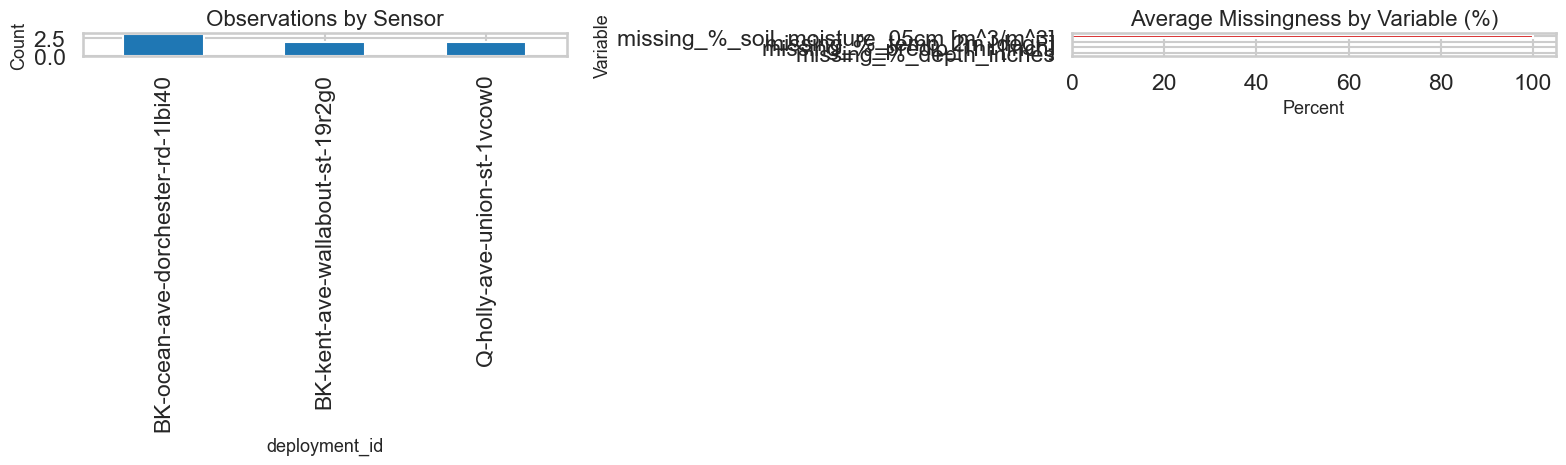

In [52]:
qaqc = (
    df_storms.sort_values(["deployment_id", "time"])
    .groupby("deployment_id")
    .agg(
        n_obs=("time", "size"),
        start_time=("time", "min"),
        end_time=("time", "max"),
        median_depth=("depth_inches", "median"),
        max_depth=("depth_inches", "max"),
    )
)

qaqc["record_days"] = (qaqc["end_time"] - qaqc["start_time"]).dt.total_seconds() / 86400

missing_pct = (
    df_storms.groupby("deployment_id")[KEY_VARS]
    .apply(lambda x: x.isna().mean() * 100)
    .add_prefix("missing_%_")
)

qaqc = qaqc.join(missing_pct)

median_step_min = (
    df_storms.sort_values(["deployment_id", "time"]) 
    .groupby("deployment_id")["time"]
    .diff()
    .dt.total_seconds()
    .div(60)
)
qaqc["median_timestep_min"] = median_step_min.groupby(df_storms["deployment_id"]).median().values

display(qaqc.sort_values("n_obs", ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
qaqc["n_obs"].sort_values(ascending=False).plot(kind="bar", ax=axes[0], color="#1f77b4")
axes[0].set_title("Observations by Sensor")
axes[0].set_xlabel("deployment_id")
axes[0].set_ylabel("Count")

qaqc.filter(like="missing_%_").mean().sort_values().plot(kind="barh", ax=axes[1], color="#d62728")
axes[1].set_title("Average Missingness by Variable (%)")
axes[1].set_xlabel("Percent")
axes[1].set_ylabel("Variable")

plt.tight_layout()
plt.show()
        


### 3) Event Signatures (Hydrology Core Table)

Create event-level hydrologic signatures per sensor:
- event duration,
- total precipitation,
- peak depth,
- lag-to-peak, and
- response ratio (peak depth / total precip).
        


In [53]:
def build_event_signatures(df, gap_minutes=120):
    required = [
        "deployment_id",
        "time",
        "depth_inches",
        "precip_1hr [inch]",
        "soil_moisture_05cm [m^3/m^3]",
        "elevation [feet]",
        "latitude",
        "longitude",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    data = df[required].copy().sort_values(["deployment_id", "time"])
    data["time_diff_min"] = (
        data.groupby("deployment_id")["time"].diff().dt.total_seconds() / 60
    )
    data["new_event"] = data["time_diff_min"].isna() | (data["time_diff_min"] > gap_minutes)
    data["event_id"] = data.groupby("deployment_id")["new_event"].cumsum().astype(int)

    grouped = data.groupby(["deployment_id", "event_id"], as_index=False)
    events = grouped.agg(
        event_start=("time", "min"),
        event_end=("time", "max"),
        n_points=("time", "size"),
        total_precip=("precip_1hr [inch]", "sum"),
        peak_depth=("depth_inches", "max"),
        antecedent_moisture=("soil_moisture_05cm [m^3/m^3]", "first"),
        elevation_ft=("elevation [feet]", "first"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
    )

    peak_times = (
        data.sort_values("depth_inches", ascending=False)
        .groupby(["deployment_id", "event_id"], as_index=False)
        .first()[["deployment_id", "event_id", "time"]]
        .rename(columns={"time": "peak_time"})
    )
    events = events.merge(peak_times, on=["deployment_id", "event_id"], how="left")

    events["duration_hr"] = (events["event_end"] - events["event_start"]).dt.total_seconds() / 3600
    events["lag_to_peak_min"] = (events["peak_time"] - events["event_start"]).dt.total_seconds() / 60
    events["response_ratio"] = np.where(events["total_precip"] > 0, events["peak_depth"] / events["total_precip"], np.nan)

    # Keep hydrologically meaningful rainfall events.
    events = events[(events["total_precip"] > 0) & (events["n_points"] >= 3)].copy()
    return events.sort_values(["deployment_id", "event_start"]).reset_index(drop=True)


events_120 = build_event_signatures(df_storms, gap_minutes=PRESENTATION_GAP_MIN)
print(f"Event rows: {len(events_120):,}")
display(events_120.head(10))

events_120[["total_precip", "peak_depth", "duration_hr", "lag_to_peak_min", "response_ratio"]].describe().T
        


Event rows: 0


,deployment_id,event_id,event_start,event_end,n_points,total_precip,peak_depth,antecedent_moisture,elevation_ft,latitude,longitude,peak_time,duration_hr,lag_to_peak_min,response_ratio


,count,mean,std,min,25%,50%,75%,max
total_precip,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
peak_depth,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_hr,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lag_to_peak_min,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
response_ratio,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4) Antecedent Moisture Classes and Response

Bin events by antecedent moisture (Dry, Normal, Wet) and compare peak depth and lag behavior.
        


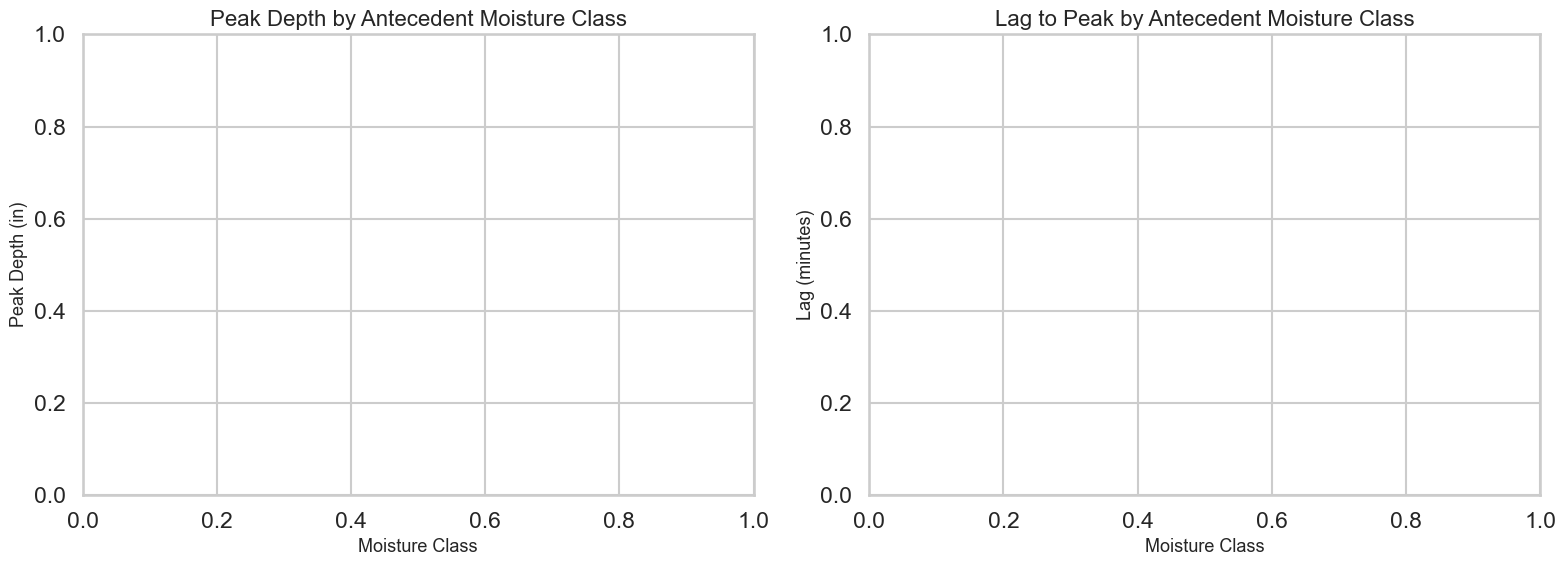

,n_events,median_peak_depth,median_lag_min,median_response_ratio
moisture_class,,,,


In [54]:
events_m = events_120.dropna(subset=["antecedent_moisture", "peak_depth", "lag_to_peak_min"]).copy()

if events_m["antecedent_moisture"].nunique() >= 3:
    events_m["moisture_class"] = pd.qcut(
        events_m["antecedent_moisture"],
        q=3,
        labels=["Dry", "Normal", "Wet"],
        duplicates="drop",
    )
else:
    events_m["moisture_class"] = "All"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=events_m, x="moisture_class", y="peak_depth", ax=axes[0], palette="Blues")
axes[0].set_title("Peak Depth by Antecedent Moisture Class")
axes[0].set_xlabel("Moisture Class")
axes[0].set_ylabel("Peak Depth (in)")

sns.boxplot(data=events_m, x="moisture_class", y="lag_to_peak_min", ax=axes[1], palette="Greens")
axes[1].set_title("Lag to Peak by Antecedent Moisture Class")
axes[1].set_xlabel("Moisture Class")
axes[1].set_ylabel("Lag (minutes)")

plt.tight_layout()
plt.show()

class_summary = events_m.groupby("moisture_class", observed=False).agg(
    n_events=("event_id", "size"),
    median_peak_depth=("peak_depth", "median"),
    median_lag_min=("lag_to_peak_min", "median"),
    median_response_ratio=("response_ratio", "median"),
)
display(class_summary)
        


### 5) Event Definition Sensitivity (60/120/180 min)

Check how inter-event threshold selection affects event counts and key signatures.
        


,gap_min,n_events,median_total_precip,median_peak_depth,median_lag_to_peak_min,median_response_ratio
0,60,85,1.102083,0.708661,296.981717,0.151494
1,120,76,1.237667,0.728346,349.482525,0.232844
2,180,76,1.237667,0.728346,349.482525,0.232844


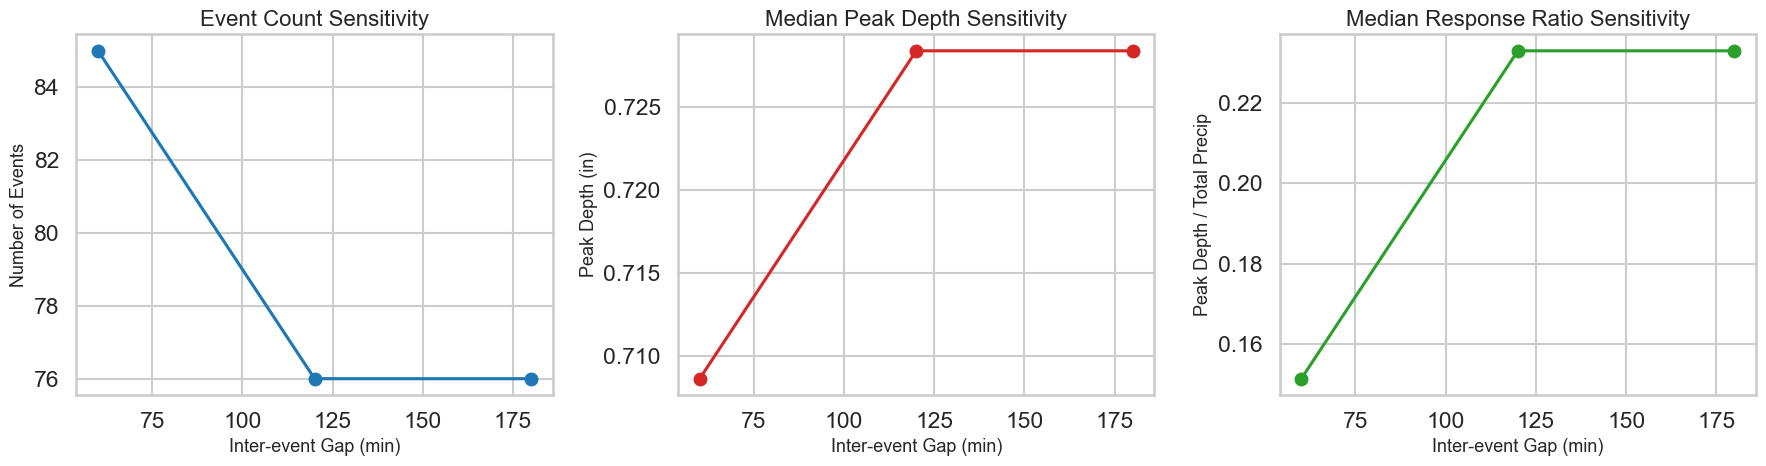

In [ ]:
sensitivity_rows = []
for gap in [60, 120, 180]:
    ev = build_event_signatures(df_storms, gap_minutes=gap)
    sensitivity_rows.append(
        {
            "gap_min": gap,
            "n_events": len(ev),
            "median_total_precip": ev["total_precip"].median(),
            "median_peak_depth": ev["peak_depth"].median(),
            "median_lag_to_peak_min": ev["lag_to_peak_min"].median(),
            "median_response_ratio": ev["response_ratio"].median(),
        }
    )

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(sensitivity_df["gap_min"], sensitivity_df["n_events"], marker="o", color="#1f77b4")
axes[0].set_title("Event Count Sensitivity")
axes[0].set_xlabel("Inter-event Gap (min)")
axes[0].set_ylabel("Number of Events")

axes[1].plot(sensitivity_df["gap_min"], sensitivity_df["median_peak_depth"], marker="o", color="#d62728")
axes[1].set_title("Median Peak Depth Sensitivity")
axes[1].set_xlabel("Inter-event Gap (min)")
axes[1].set_ylabel("Peak Depth (in)")

axes[2].plot(sensitivity_df["gap_min"], sensitivity_df["median_response_ratio"], marker="o", color="#2ca02c")
axes[2].set_title("Median Response Ratio Sensitivity")
axes[2].set_xlabel("Inter-event Gap (min)")
axes[2].set_ylabel("Peak Depth / Total Precip")

plt.tight_layout()
plt.show()
        


### 6) Exceedance and Frequency Context

Show empirical exceedance behavior of event peak depths to communicate risk context.
        


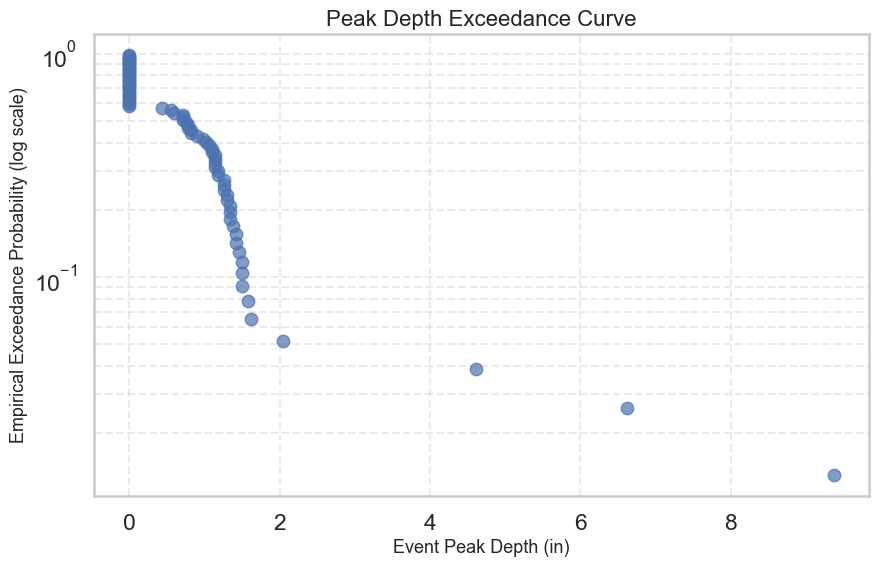

In [ ]:
ex = events_120[["peak_depth"]].dropna().sort_values("peak_depth", ascending=False).reset_index(drop=True)
ex["rank"] = np.arange(1, len(ex) + 1)
ex["exceedance_prob"] = ex["rank"] / (len(ex) + 1)

plt.figure(figsize=(10, 6))
plt.plot(ex["peak_depth"], ex["exceedance_prob"], marker="o", linestyle="none", alpha=0.7)
plt.yscale("log")
plt.xlabel("Event Peak Depth (in)")
plt.ylabel("Empirical Exceedance Probability (log scale)")
plt.title("Peak Depth Exceedance Curve")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()
        


### 7) Spatial Variability Summary

Aggregate event signatures by sensor and compare hydrologic response across space and elevation.
        


,deployment_id,n_events,median_peak_depth,median_response_ratio,median_lag_to_peak,elevation_ft,latitude,longitude
0,apparently-darling-gecko,50,1.122047,0.602545,352.482642,82,40.883259,-73.905853
1,simply-solid-cub,12,0.000000,0.000000,330.495033,24,40.736702,-73.778412
2,tender_white_deer,14,0.000000,0.000000,346.491758,52,40.650532,-73.972237


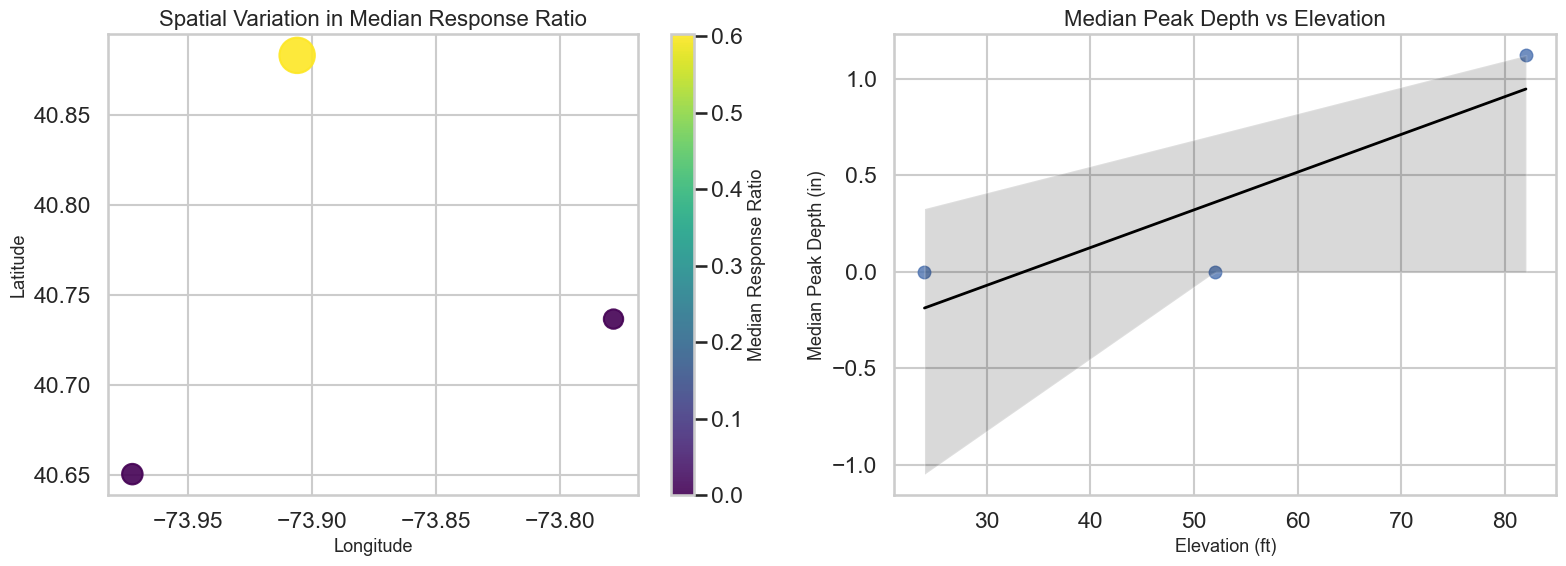

In [ ]:
sensor_event_summary = events_120.groupby("deployment_id", as_index=False).agg(
    n_events=("event_id", "size"),
    median_peak_depth=("peak_depth", "median"),
    median_response_ratio=("response_ratio", "median"),
    median_lag_to_peak=("lag_to_peak_min", "median"),
    elevation_ft=("elevation_ft", "first"),
    latitude=("latitude", "first"),
    longitude=("longitude", "first"),
)

display(sensor_event_summary.sort_values("median_peak_depth", ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(
    sensor_event_summary["longitude"],
    sensor_event_summary["latitude"],
    c=sensor_event_summary["median_response_ratio"],
    s=50 + 12 * sensor_event_summary["n_events"],
    cmap="viridis",
    alpha=0.9,
)
axes[0].set_title("Spatial Variation in Median Response Ratio")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(sc, ax=axes[0], label="Median Response Ratio")

sns.regplot(
    data=sensor_event_summary,
    x="elevation_ft",
    y="median_peak_depth",
    ax=axes[1],
    scatter_kws={"alpha": 0.8},
    line_kws={"color": "black", "lw": 2},
)
axes[1].set_title("Median Peak Depth vs Elevation")
axes[1].set_xlabel("Elevation (ft)")
axes[1].set_ylabel("Median Peak Depth (in)")

plt.tight_layout()
plt.show()
        


### 8) Slide-Ready Figure Export

Use these helpers to consistently export figures for your deck.
        


In [ ]:
EXPORT_DIR = Path("results/presentation_figures")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def export_current_figure(name, dpi=300):
    file_name = "".join(ch if ch.isalnum() or ch in ["_", "-"] else "_" for ch in name.strip().lower())
    out_path = EXPORT_DIR / f"{file_name}.png"
    plt.gcf().savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out_path}")


print(f"Export directory: {EXPORT_DIR.resolve()}")
print("After creating any figure, run: export_current_figure('figure_name')")
        


Export directory: /sfs/gpfs/tardis/home/upw4ys/Documents/floodnet_work/Finalized_Scripts/results/presentation_figures
After creating any figure, run: export_current_figure('figure_name')


## Additional Graph Types for Presentation

These plots add alternative visual perspectives often expected in hydrology talks: density, seasonality, distribution shape, and sensor ranking.
    


### 9) Event Response Density (Hexbin)

Visualize nonlinear response between event rainfall and peak flood depth.
    


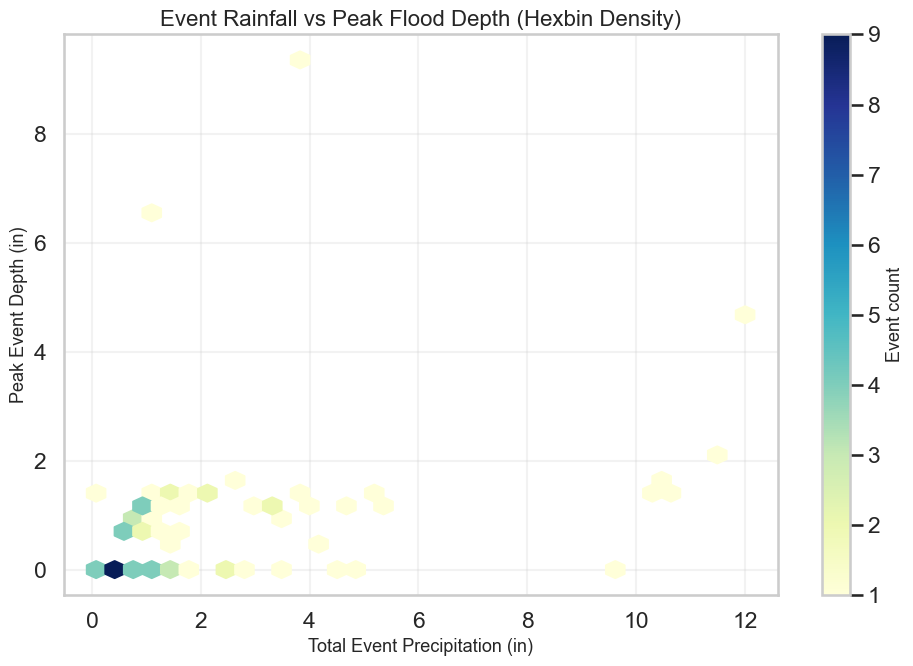

In [ ]:
if "events_120" not in globals():
    if "build_event_signatures" in globals():
        events_120 = build_event_signatures(df_storms, gap_minutes=120)
    else:
        raise NameError("events_120 not found and build_event_signatures is not defined.")

hex_df = events_120.dropna(subset=["total_precip", "peak_depth"]).copy()
hex_df = hex_df[(hex_df["total_precip"] > 0) & (hex_df["peak_depth"] >= 0)]

plt.figure(figsize=(10, 7))
plt.hexbin(
    hex_df["total_precip"],
    hex_df["peak_depth"],
    gridsize=35,
    cmap="YlGnBu",
    mincnt=1,
)
cb = plt.colorbar()
cb.set_label("Event count")
plt.xlabel("Total Event Precipitation (in)")
plt.ylabel("Peak Event Depth (in)")
plt.title("Event Rainfall vs Peak Flood Depth (Hexbin Density)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
    


### 10) Exceedance by Moisture Regime (ECDF)

Compare flood-depth exceedance behavior under Dry/Normal/Wet antecedent moisture classes.
    


In [ ]:
ecdf_df = events_120.dropna(subset=["antecedent_moisture", "peak_depth"]).copy()
if len(ecdf_df) == 0:
    raise ValueError("No rows available for ECDF moisture-class plot.")

if "moisture_class" not in ecdf_df.columns:
    if ecdf_df["antecedent_moisture"].nunique() >= 3:
        ecdf_df["moisture_class"] = pd.qcut(
            ecdf_df["antecedent_moisture"],
            q=3,
            labels=["Dry", "Normal", "Wet"],
            duplicates="drop",
        )
    else:
        ecdf_df["moisture_class"] = "All"

plt.figure(figsize=(10, 6))
for cls, sub in ecdf_df.groupby("moisture_class", observed=False):
    vals = np.sort(sub["peak_depth"].values)
    y = np.arange(1, len(vals) + 1) / len(vals)
    plt.step(vals, y, where="post", linewidth=2, label=str(cls))

plt.xlabel("Peak Event Depth (in)")
plt.ylabel("Cumulative Probability")
plt.title("ECDF of Peak Depth by Antecedent Moisture Class")
plt.legend(title="Moisture Class")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
    


ValueError: No rows available for ECDF moisture-class plot.

### 11) Year-Month Event Heatmap

Show seasonality and interannual variability in event frequency.
    


ValueError: Unknown format code 'd' for object of type 'float'

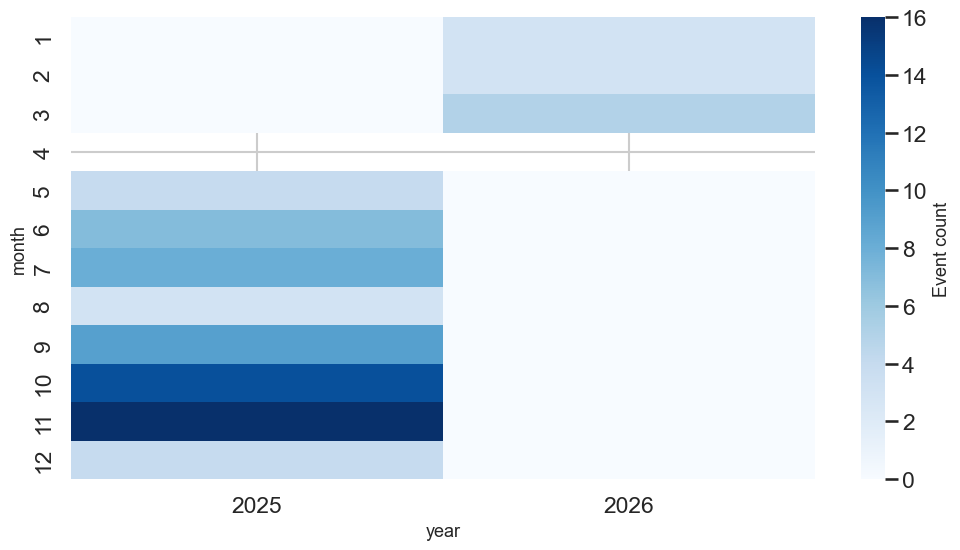

In [ ]:
hm_df = events_120.dropna(subset=["event_start"]).copy()
hm_df["year"] = hm_df["event_start"].dt.year
hm_df["month"] = hm_df["event_start"].dt.month

pivot_counts = hm_df.pivot_table(
    index="month",
    columns="year",
    values="event_id",
    aggfunc="count",
    fill_value=0,
)

month_order = list(range(1, 13))
pivot_counts = pivot_counts.reindex(month_order)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_counts, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Event count"})
plt.title("Event Count Heatmap by Month and Year")
plt.xlabel("Year")
plt.ylabel("Month")
plt.tight_layout()
plt.show()
    


### 12) Diurnal Flood Depth Distribution (Violin)

Summarize depth distributions by hour-of-day to inspect diurnal structure in observed water levels.
    


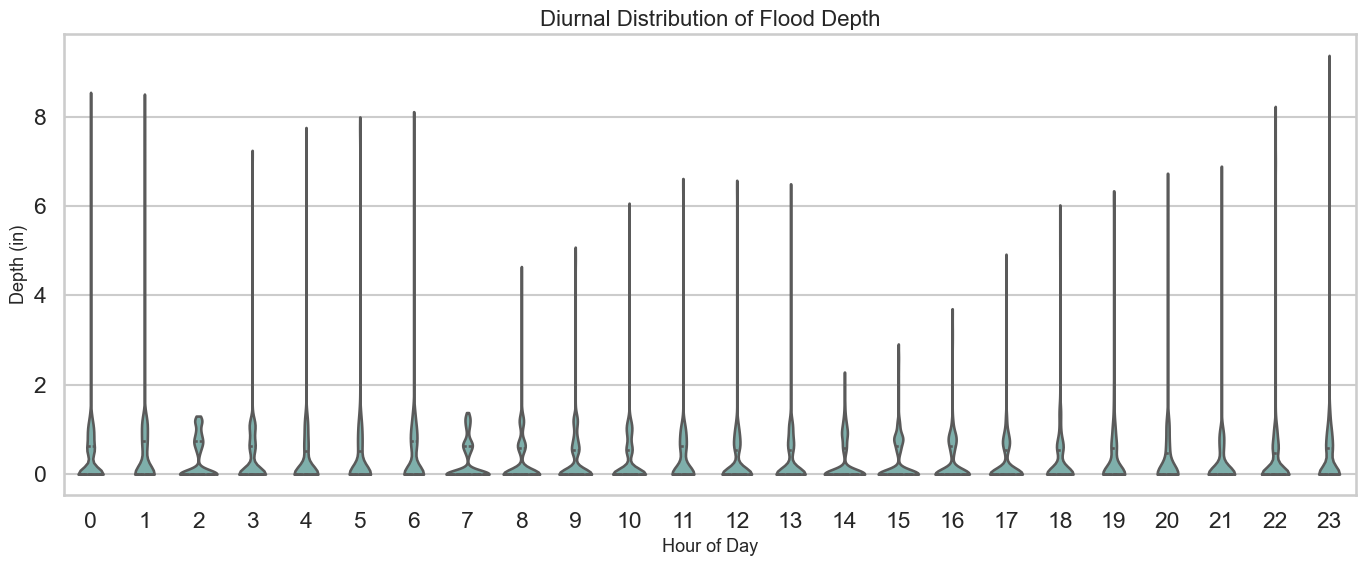

In [ ]:
diurnal = df_storms.dropna(subset=["time", "depth_inches"]).copy()
diurnal["hour"] = diurnal["time"].dt.hour

# Optional light sampling for very large datasets to keep plotting responsive.
max_rows = 200000
if len(diurnal) > max_rows:
    diurnal = diurnal.sample(max_rows, random_state=42)

plt.figure(figsize=(14, 6))
sns.violinplot(data=diurnal, x="hour", y="depth_inches", inner="quartile", cut=0, color="#76b7b2")
plt.title("Diurnal Distribution of Flood Depth")
plt.xlabel("Hour of Day")
plt.ylabel("Depth (in)")
plt.tight_layout()
plt.show()
    


### 13) Lag-Response Bubble Plot

Relate lag-to-peak and response ratio, with bubble size representing event rainfall depth.
    


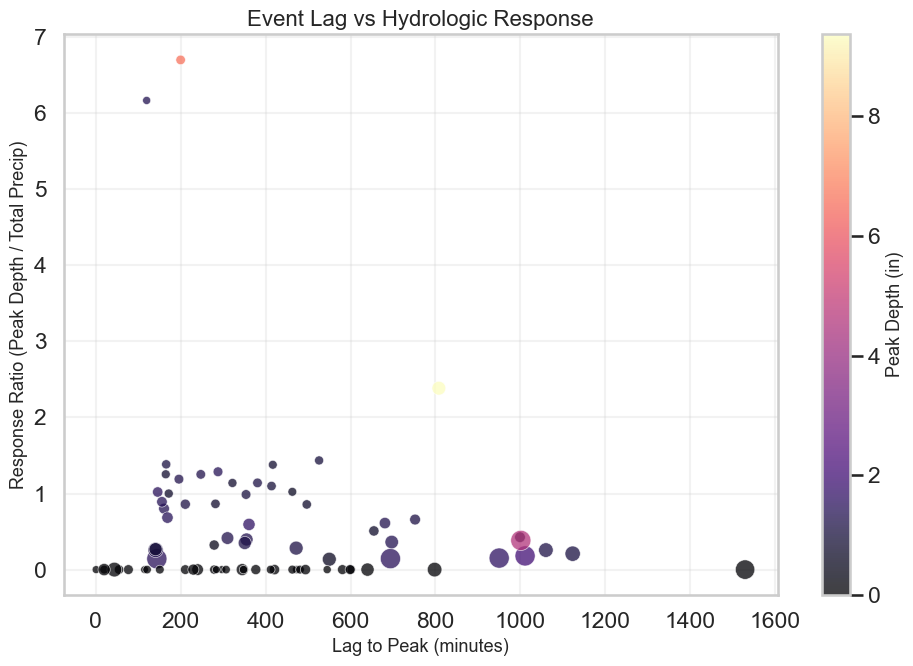

In [ ]:
bubble = events_120.dropna(subset=["lag_to_peak_min", "response_ratio", "total_precip"]).copy()
bubble = bubble[bubble["total_precip"] > 0]

if bubble["antecedent_moisture"].notna().any():
    color_values = bubble["antecedent_moisture"]
    cbar_label = "Antecedent Moisture"
    cmap = "viridis"
else:
    color_values = bubble["peak_depth"]
    cbar_label = "Peak Depth (in)"
    cmap = "magma"

plt.figure(figsize=(10, 7))
sc = plt.scatter(
    bubble["lag_to_peak_min"],
    bubble["response_ratio"],
    c=color_values,
    cmap=cmap,
    s=30 + 180 * (bubble["total_precip"] / bubble["total_precip"].quantile(0.95)).clip(0, 1),
    alpha=0.75,
    edgecolors="white",
    linewidth=0.5,
)
plt.colorbar(sc, label=cbar_label)
plt.xlabel("Lag to Peak (minutes)")
plt.ylabel("Response Ratio (Peak Depth / Total Precip)")
plt.title("Event Lag vs Hydrologic Response")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
    


### 14) Sensor Ranking (Lollipop)

Rank sensors by median event peak depth for a concise spatial performance narrative.
    


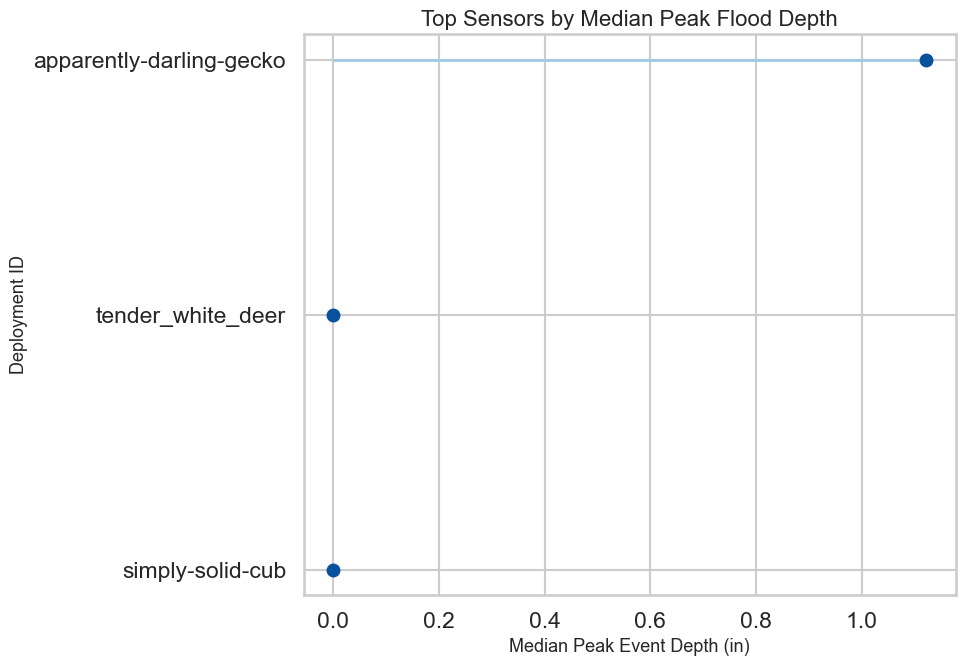

In [ ]:
if "sensor_event_summary" not in globals():
    sensor_event_summary = events_120.groupby("deployment_id", as_index=False).agg(
        n_events=("event_id", "size"),
        median_peak_depth=("peak_depth", "median"),
    )

rank_df = sensor_event_summary.dropna(subset=["median_peak_depth"]).copy()
rank_df = rank_df.sort_values("median_peak_depth", ascending=False).head(15)
rank_df = rank_df.sort_values("median_peak_depth")

plt.figure(figsize=(10, 7))
plt.hlines(y=rank_df["deployment_id"], xmin=0, xmax=rank_df["median_peak_depth"], color="#9ecae1", linewidth=2)
plt.plot(rank_df["median_peak_depth"], rank_df["deployment_id"], "o", color="#08519c")
plt.xlabel("Median Peak Event Depth (in)")
plt.ylabel("Deployment ID")
plt.title("Top Sensors by Median Peak Flood Depth")
plt.tight_layout()
plt.show()
    


## Rain Influence Diagnostics

This section adds rain-response-specific metrics and visuals for the rain-influenced subset.
It focuses on event-level precipitation-to-depth coupling and dry-period variability (tidal proxy).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prefer the notebook's loaded dataframe.
if 'df_storms' in globals() and isinstance(df_storms, pd.DataFrame):
    df = df_storms
elif 'df' in globals() and isinstance(df, pd.DataFrame):
    pass
else:
    raise NameError("No dataframe found. Run the data-loading cell first (df_storms).")

required = ['deployment_id', 'total_precip_in', 'net_depth_rise_in', 'precip_1hr [inch]', 'depth_inches']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns for rain influence diagnostics: {missing}')

storm_col = 'global_storm_id' if 'global_storm_id' in df.columns else ('storm_id' if 'storm_id' in df.columns else None)
if storm_col is None:
    raise ValueError('Expected one of global_storm_id or storm_id in dataframe')

storm_level = (
    df[['deployment_id', storm_col, 'total_precip_in', 'net_depth_rise_in']]
    .dropna(subset=['deployment_id', storm_col, 'total_precip_in', 'net_depth_rise_in'])
    .drop_duplicates(['deployment_id', storm_col])
)
wet = storm_level[storm_level['total_precip_in'] >= 0.05].copy()

rows = []
for did, g in wet.groupby('deployment_id', sort=False):
    x = g['total_precip_in'].to_numpy(dtype=float)
    y = g['net_depth_rise_in'].to_numpy(dtype=float)
    corr = np.nan
    slope = np.nan
    if len(g) >= 2 and np.nanstd(x) > 0 and np.nanstd(y) > 0:
        corr = float(np.corrcoef(x, y)[0, 1])
        slope = float(np.polyfit(x, y, 1)[0])
    rows.append({
        'deployment_id': did,
        'n_wet_events': len(g),
        'corr_precip_depth': corr,
        'slope_in_per_in': slope,
        'wet_positive_frac': float((g['net_depth_rise_in'] > 0.02).mean())
    })

rain_influence_summary = pd.DataFrame(rows)
dry = (
    df[df['precip_1hr [inch]'] <= 0.001]
    .groupby('deployment_id')['depth_inches']
    .agg(dry_depth_std='std', dry_n='size')
    .reset_index()
)
rain_influence_summary = rain_influence_summary.merge(dry, on='deployment_id', how='left')

for c in ['corr_precip_depth', 'slope_in_per_in', 'wet_positive_frac', 'dry_depth_std']:
    vals = rain_influence_summary[c].astype(float)
    lo, hi = np.nanpercentile(vals, 5), np.nanpercentile(vals, 95)
    if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
        rain_influence_summary[c + '_z'] = ((vals - lo) / (hi - lo)).clip(0, 1)
    else:
        rain_influence_summary[c + '_z'] = np.nan

penalty_fill = rain_influence_summary['dry_depth_std_z'].median()
if pd.isna(penalty_fill):
    penalty_fill = 0

rain_influence_summary['rain_influence_score'] = (
    0.45 * rain_influence_summary['corr_precip_depth_z'].fillna(0)
    + 0.35 * rain_influence_summary['slope_in_per_in_z'].fillna(0)
    + 0.20 * rain_influence_summary['wet_positive_frac_z'].fillna(0)
    - 0.25 * rain_influence_summary['dry_depth_std_z'].fillna(penalty_fill)
)

rain_influence_summary = rain_influence_summary.sort_values('rain_influence_score', ascending=False).reset_index(drop=True)
display(rain_influence_summary.head(15))


,deployment_id,n_wet_events,corr_precip_depth,slope_in_per_in,wet_positive_frac,dry_depth_std,dry_n,corr_precip_depth_z,slope_in_per_in_z,wet_positive_frac_z,dry_depth_std_z,rain_influence_score
0,simply-solid-cub,12,0.763018,0.255195,0.083333,0.000000,5667,0.868103,1.000000,0.021465,0.0,0.744939
1,tender_white_deer,15,0.838805,0.137069,0.066667,0.000000,5209,1.000000,0.000000,0.000000,0.0,0.450000
2,apparently-darling-gecko,51,0.264217,0.158758,0.843137,0.608426,20082,0.000000,0.183605,1.000000,1.0,0.014262


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prefer the notebook's loaded dataframe.
if 'df_storms' in globals() and isinstance(df_storms, pd.DataFrame):
    df = df_storms
elif 'df' in globals() and isinstance(df, pd.DataFrame):
    pass
else:
    raise NameError("No dataframe found. Run the data-loading cell first (df_storms).")

required = ['deployment_id', 'total_precip_in', 'net_depth_rise_in', 'precip_1hr [inch]', 'depth_inches']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns for rain influence diagnostics: {missing}')

storm_col = 'global_storm_id' if 'global_storm_id' in df.columns else ('storm_id' if 'storm_id' in df.columns else None)
if storm_col is None:
    raise ValueError('Expected one of global_storm_id or storm_id in dataframe')

storm_level = (
    df[['deployment_id', storm_col, 'total_precip_in', 'net_depth_rise_in']]
    .dropna(subset=['deployment_id', storm_col, 'total_precip_in', 'net_depth_rise_in'])
    .drop_duplicates(['deployment_id', storm_col])
)
wet = storm_level[storm_level['total_precip_in'] >= 0.05].copy()

rows = []
for did, g in wet.groupby('deployment_id', sort=False):
    x = g['total_precip_in'].to_numpy(dtype=float)
    y = g['net_depth_rise_in'].to_numpy(dtype=float)
    corr = np.nan
    slope = np.nan
    if len(g) >= 2 and np.nanstd(x) > 0 and np.nanstd(y) > 0:
        corr = float(np.corrcoef(x, y)[0, 1])
        slope = float(np.polyfit(x, y, 1)[0])
    rows.append({
        'deployment_id': did,
        'n_wet_events': len(g),
        'corr_precip_depth': corr,
        'slope_in_per_in': slope,
        'wet_positive_frac': float((g['net_depth_rise_in'] > 0.02).mean())
    })

rain_influence_summary = pd.DataFrame(rows)
dry = (
    df[df['precip_1hr [inch]'] <= 0.001]
    .groupby('deployment_id')['depth_inches']
    .agg(dry_depth_std='std', dry_n='size')
    .reset_index()
)
rain_influence_summary = rain_influence_summary.merge(dry, on='deployment_id', how='left')

for c in ['corr_precip_depth', 'slope_in_per_in', 'wet_positive_frac', 'dry_depth_std']:
    vals = rain_influence_summary[c].astype(float)
    lo, hi = np.nanpercentile(vals, 5), np.nanpercentile(vals, 95)
    if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
        rain_influence_summary[c + '_z'] = ((vals - lo) / (hi - lo)).clip(0, 1)
    else:
        rain_influence_summary[c + '_z'] = np.nan

penalty_fill = rain_influence_summary['dry_depth_std_z'].median()
if pd.isna(penalty_fill):
    penalty_fill = 0

rain_influence_summary['rain_influence_score'] = (
    0.45 * rain_influence_summary['corr_precip_depth_z'].fillna(0)
    + 0.35 * rain_influence_summary['slope_in_per_in_z'].fillna(0)
    + 0.20 * rain_influence_summary['wet_positive_frac_z'].fillna(0)
    - 0.25 * rain_influence_summary['dry_depth_std_z'].fillna(penalty_fill)
)

rain_influence_summary = rain_influence_summary.sort_values('rain_influence_score', ascending=False).reset_index(drop=True)
display(rain_influence_summary.head(15))


,deployment_id,n_wet_events,corr_precip_depth,slope_in_per_in,wet_positive_frac,dry_depth_std,dry_n,corr_precip_depth_z,slope_in_per_in_z,wet_positive_frac_z,dry_depth_std_z,rain_influence_score
0,apparently-darling-gecko,51,0.264217,0.158758,0.843137,0.608426,20082,NaN,NaN,NaN,NaN,0.0
